In [ ]:
from google.colab import files

uploaded = files.upload()

Saving tmdb_movies_clean.csv to tmdb_movies_clean.csv


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    hamming_loss,
    classification_report
)

df = pd.read_csv("tmdb_movies_clean.csv")

print(df.shape)

(8985, 7)


In [ ]:
X = df["overview"]
y = df["genres"]

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(6289,)
(1348,)
(1348,)


In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

X_train_clean = X_train.apply(clean_text)
X_val_clean = X_val.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

In [ ]:
all_genres = sorted(
    set(
        genre
        for genres in y_train
        for genre in genres.split("|")
    )
)

genre_to_idx = {
    genre: idx
    for idx, genre in enumerate(all_genres)
}

print("Genres:", len(all_genres))
print(all_genres)

Genres: 19
['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


In [ ]:
def encode_genres(genre_string):
    vector = np.zeros(len(all_genres), dtype=int)

    for genre in genre_string.split("|"):
        vector[genre_to_idx[genre]] = 1

    return vector

y_train_encoded = np.array(
    y_train.apply(encode_genres).tolist()
)

y_val_encoded = np.array(
    y_val.apply(encode_genres).tolist()
)

y_test_encoded = np.array(
    y_test.apply(encode_genres).tolist()
)

print(y_train_encoded.shape)

(6289, 19)


In [ ]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train_clean)

X_val_tfidf = tfidf.transform(X_val_clean)

X_test_tfidf = tfidf.transform(X_test_clean)

print("Train:", X_train_tfidf.shape)
print("Validation:", X_val_tfidf.shape)
print("Test:", X_test_tfidf.shape)

Train: (6289, 20000)
Validation: (1348, 20000)
Test: (1348, 20000)


In [ ]:
model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        C=1.0
    )
)

model.fit(
    X_train_tfidf,
    y_train_encoded
)

print("Training completed!")

Training completed!


In [ ]:
y_test_prob = model.predict_proba(X_test_tfidf)

print(y_test_prob.shape)

(1348, 19)


In [ ]:
THRESHOLD = 0.3

y_test_pred = (
    y_test_prob >= THRESHOLD
).astype(int)

In [ ]:
print("Micro F1:",
      f1_score(
          y_test_encoded,
          y_test_pred,
          average="micro"
      ))

print("Macro F1:",
      f1_score(
          y_test_encoded,
          y_test_pred,
          average="macro"
      ))

print("Micro Precision:",
      precision_score(
          y_test_encoded,
          y_test_pred,
          average="micro",
          zero_division=0
      ))

print("Micro Recall:",
      recall_score(
          y_test_encoded,
          y_test_pred,
          average="micro",
          zero_division=0
      ))

print("Hamming Loss:",
      hamming_loss(
          y_test_encoded,
          y_test_pred
      ))

Micro F1: 0.5540582889376371
Macro F1: 0.33302588626691704
Micro Precision: 0.5952861952861953
Micro Recall: 0.5181711606096131
Hamming Loss: 0.1111197875995627


In [ ]:
print(
    classification_report(
        y_test_encoded,
        y_test_pred,
        target_names=all_genres,
        zero_division=0
    )
)

                 precision    recall  f1-score   support

         Action       0.61      0.78      0.68       389
      Adventure       0.58      0.43      0.49       222
      Animation       0.82      0.20      0.32       140
         Comedy       0.52      0.72      0.61       366
          Crime       0.77      0.46      0.58       234
    Documentary       0.00      0.00      0.00        35
          Drama       0.55      0.90      0.68       590
         Family       0.87      0.15      0.26       131
        Fantasy       0.84      0.17      0.28       159
        History       0.83      0.08      0.15        61
         Horror       0.75      0.30      0.42       159
          Music       0.00      0.00      0.00        36
        Mystery       0.80      0.04      0.07       106
        Romance       0.60      0.35      0.44       168
Science Fiction       0.88      0.32      0.47       190
       TV Movie       0.00      0.00      0.00        14
       Thriller       0.57    

In [ ]:
movie = [
    "A group of astronauts travel through space "
    "to discover a new planet and save humanity."
]

movie_tfidf = tfidf.transform(movie)

probabilities = model.predict_proba(movie_tfidf)[0]

predicted_genres = [
    all_genres[i]
    for i, probability in enumerate(probabilities)
    if probability >= 0.35
]

print("Predicted genres:", predicted_genres)

Predicted genres: ['Action', 'Adventure', 'Science Fiction']


In [ ]:
# Probabilities
y_train_prob = model.predict_proba(X_train_tfidf)
y_val_prob = model.predict_proba(X_val_tfidf)
y_test_prob = model.predict_proba(X_test_tfidf)

# Convert probabilities to labels
THRESHOLD = 0.5

y_train_pred = (y_train_prob >= THRESHOLD).astype(int)
y_val_pred = (y_val_prob >= THRESHOLD).astype(int)
y_test_pred = (y_test_prob >= THRESHOLD).astype(int)

In [ ]:
def calculate_metrics(y_true, y_pred):
    return {
        "Micro F1": f1_score(y_true, y_pred, average="micro"),
        "Macro F1": f1_score(y_true, y_pred, average="macro"),
        "Precision": precision_score(
            y_true, y_pred, average="micro", zero_division=0
        ),
        "Recall": recall_score(
            y_true, y_pred, average="micro", zero_division=0
        ),
        "Hamming Loss": hamming_loss(y_true, y_pred)
    }


train_metrics = calculate_metrics(y_train_encoded, y_train_pred)
val_metrics = calculate_metrics(y_val_encoded, y_val_pred)
test_metrics = calculate_metrics(y_test_encoded, y_test_pred)

print("Train:", train_metrics)
print("Validation:", val_metrics)
print("Test:", test_metrics)

Train: {'Micro F1': 0.4809384164222874, 'Macro F1': 0.22955321727383665, 'Precision': 0.9515253602844844, 'Recall': 0.32179251851383, 'Hamming Loss': 0.09183955276966466}
Validation: {'Micro F1': 0.3103529969201611, 'Macro F1': 0.13782180542295244, 'Precision': 0.7797619047619048, 'Recall': 0.19372966577935521, 'Hamming Loss': 0.11365766047165392}
Test: {'Micro F1': 0.30780075187969924, 'Macro F1': 0.13503225161716867, 'Precision': 0.7760663507109005, 'Recall': 0.19196951934349354, 'Hamming Loss': 0.11502420740277995}


In [ ]:
metrics_df = pd.DataFrame(
    [train_metrics, val_metrics, test_metrics],
    index=["Train", "Validation", "Test"]
)

metrics_df

,Micro F1,Macro F1,Precision,Recall,Hamming Loss
Train,0.480938,0.229553,0.951525,0.321793,0.091840
Validation,0.310353,0.137822,0.779762,0.193730,0.113658
Test,0.307801,0.135032,0.776066,0.191970,0.115024


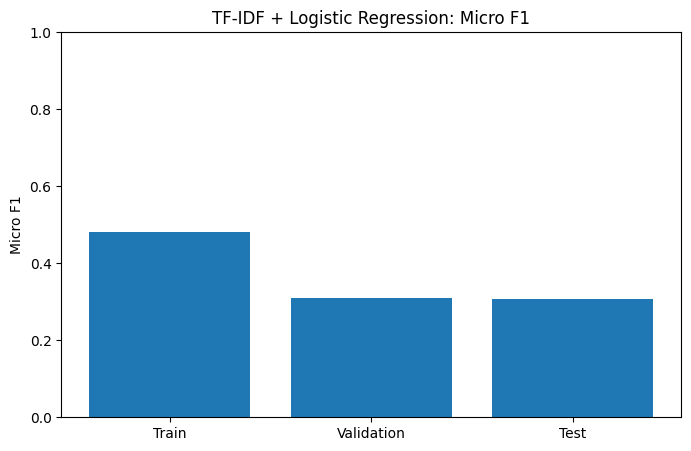

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    metrics_df.index,
    metrics_df["Micro F1"]
)

plt.ylabel("Micro F1")
plt.title("TF-IDF + Logistic Regression: Micro F1")
plt.ylim(0, 1)

plt.show()

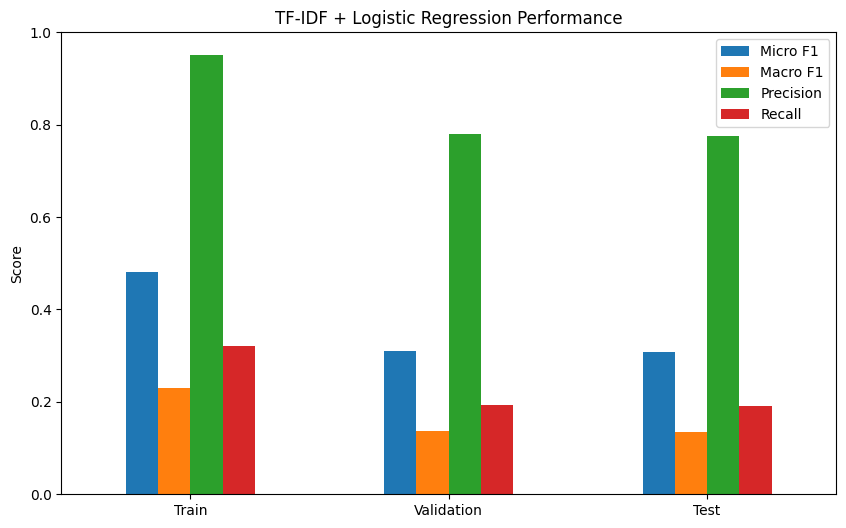

In [ ]:
metrics_to_plot = [
    "Micro F1",
    "Macro F1",
    "Precision",
    "Recall"
]

metrics_df[metrics_to_plot].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("Score")
plt.title("TF-IDF + Logistic Regression Performance")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [ ]:
thresholds = np.arange(0.10, 0.51, 0.05)

results = []

for threshold in thresholds:

    y_val_pred_temp = (
        y_val_prob >= threshold
    ).astype(int)

    micro_f1 = f1_score(
        y_val_encoded,
        y_val_pred_temp,
        average="micro"
    )

    results.append({
        "Threshold": round(threshold, 2),
        "Micro F1": micro_f1
    })

threshold_df = pd.DataFrame(results)

print(threshold_df)

   Threshold  Micro F1
0       0.10  0.429156
1       0.15  0.507299
2       0.20  0.550553
3       0.25  0.560471
4       0.30  0.542233
5       0.35  0.505162
6       0.40  0.453063
7       0.45  0.386914
8       0.50  0.310353


In [ ]:
best_row = threshold_df.loc[
    threshold_df["Micro F1"].idxmax()
]

BEST_THRESHOLD = best_row["Threshold"]

print("Best threshold:", BEST_THRESHOLD)
print("Best validation Micro F1:", best_row["Micro F1"])

Best threshold: 0.25
Best validation Micro F1: 0.5604711683331051


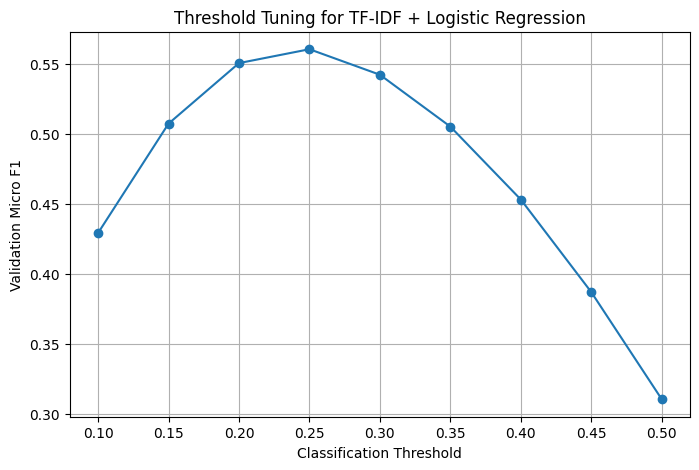

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Micro F1"],
    marker="o"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Validation Micro F1")
plt.title("Threshold Tuning for TF-IDF + Logistic Regression")
plt.grid(True)

plt.show()

In [ ]:
y_test_pred_tuned = (
    y_test_prob >= BEST_THRESHOLD
).astype(int)

In [ ]:
print("Micro F1:",
      f1_score(
          y_test_encoded,
          y_test_pred_tuned,
          average="micro"
      ))

print("Macro F1:",
      f1_score(
          y_test_encoded,
          y_test_pred_tuned,
          average="macro"
      ))

print("Precision:",
      precision_score(
          y_test_encoded,
          y_test_pred_tuned,
          average="micro",
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_test_encoded,
          y_test_pred_tuned,
          average="micro",
          zero_division=0
      ))

print("Hamming Loss:",
      hamming_loss(
          y_test_encoded,
          y_test_pred_tuned
      ))

Micro F1: 0.57014192139738
Macro F1: 0.3739205097489206
Precision: 0.5334525025536262
Recall: 0.6122508792497069
Hamming Loss: 0.12298922380134313


In [ ]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/tfidf_logistic_model.pkl")
joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")

joblib.dump(all_genres, "models/genres.pkl")
joblib.dump(BEST_THRESHOLD, "models/threshold.pkl")

print("All model files saved.")

All model files saved.


In [ ]:
loaded_model = joblib.load(
    "models/tfidf_logistic_model.pkl"
)

loaded_tfidf = joblib.load(
    "models/tfidf_vectorizer.pkl"
)

loaded_genres = joblib.load(
    "models/genres.pkl"
)

loaded_threshold = joblib.load(
    "models/threshold.pkl"
)

print("Threshold:", loaded_threshold)
print("Genres:", loaded_genres)

Threshold: 0.25
Genres: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


In [ ]:
text = [
    "A detective investigates a mysterious murder "
    "while uncovering a dangerous criminal conspiracy."
]

text_tfidf = loaded_tfidf.transform(text)

probabilities = loaded_model.predict_proba(text_tfidf)[0]

predicted_genres = [
    loaded_genres[i]
    for i, probability in enumerate(probabilities)
    if probability >= loaded_threshold
]

print("Predicted genres:", predicted_genres)

Predicted genres: ['Action', 'Crime', 'Mystery', 'Thriller']
